In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [2]:
df = pd.read_csv(
    r"C:\NeuralRetail\data\processed\cleaned_data.csv"
)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400916 entries, 0 to 400915
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      400916 non-null  int64         
 1   StockCode    400916 non-null  object        
 2   Description  400916 non-null  object        
 3   Quantity     400916 non-null  int64         
 4   InvoiceDate  400916 non-null  datetime64[ns]
 5   Price        400916 non-null  float64       
 6   Customer ID  400916 non-null  float64       
 7   Country      400916 non-null  object        
 8   Revenue      400916 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 27.5+ MB


In [6]:
daily_sales = (
    df.groupby(df["InvoiceDate"].dt.date)["Revenue"]
    .sum()
    .reset_index()
)

In [19]:
daily_sales["ds"] = pd.to_datetime(
    daily_sales["ds"]
)

In [21]:
daily_sales.dtypes

ds    datetime64[ns]
y            float64
dtype: object

In [20]:
daily_sales.columns = ["ds", "y"]

In [8]:
daily_sales.head()

,ds,y
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [9]:
daily_sales.shape

(307, 2)

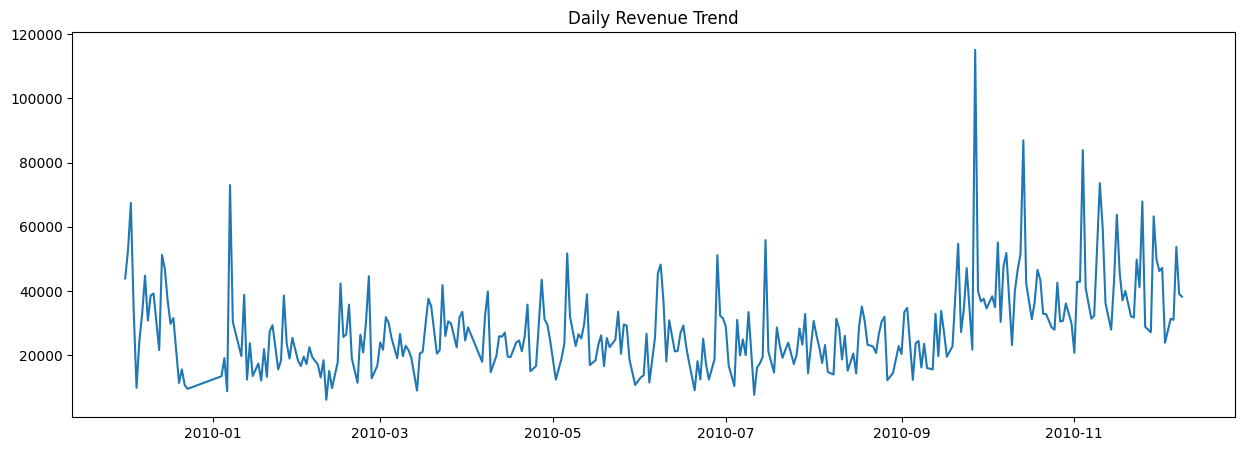

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["ds"],
    daily_sales["y"]
)

plt.title("Daily Revenue Trend")

plt.show()

In [22]:
train = daily_sales[:-30]

test = daily_sales[-30:]

In [23]:
print(train.shape)
print(test.shape)

(277, 2)
(30, 2)


In [29]:
from prophet import Prophet

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train)

13:35:51 - cmdstanpy - INFO - Chain [1] start processing
13:35:51 - cmdstanpy - INFO - Chain [1] done processing


In [30]:
future = model.make_future_dataframe(
    periods=30
)

In [31]:
forecast = model.predict(future)

In [34]:
predictions = forecast[
    ["ds", "yhat"]
].tail(30)
predictions.head()

,ds,yhat
277,2010-11-05,43844.670254
278,2010-11-06,16660.889567
279,2010-11-07,42132.692038
280,2010-11-08,53668.951611
281,2010-11-09,55614.608427


In [33]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-01,12584.783134,37202.332388,62643.966690,12584.783134,12584.783134,37587.930840,37587.930840,37587.930840,6585.659019,6585.659019,6585.659019,31002.271820,31002.271820,31002.271820,0.0,0.0,0.0,50172.713974
1,2009-12-02,12653.531628,34459.152342,59105.419613,12653.531628,12653.531628,33959.378221,33959.378221,33959.378221,3837.488034,3837.488034,3837.488034,30121.890187,30121.890187,30121.890187,0.0,0.0,0.0,46612.909850
2,2009-12-03,12722.280122,40698.703705,66435.516452,12722.280122,12722.280122,40418.420504,40418.420504,40418.420504,11316.404730,11316.404730,11316.404730,29102.015774,29102.015774,29102.015774,0.0,0.0,0.0,53140.700627
3,2009-12-04,12791.028617,30727.513214,54827.289527,12791.028617,12791.028617,29902.346075,29902.346075,29902.346075,1949.096030,1949.096030,1949.096030,27953.250045,27953.250045,27953.250045,0.0,0.0,0.0,42693.374691
4,2009-12-05,12859.777111,-127.250286,24836.636566,12859.777111,12859.777111,-251.431242,-251.431242,-251.431242,-26939.079173,-26939.079173,-26939.079173,26687.647930,26687.647930,26687.647930,0.0,0.0,0.0,12608.345869


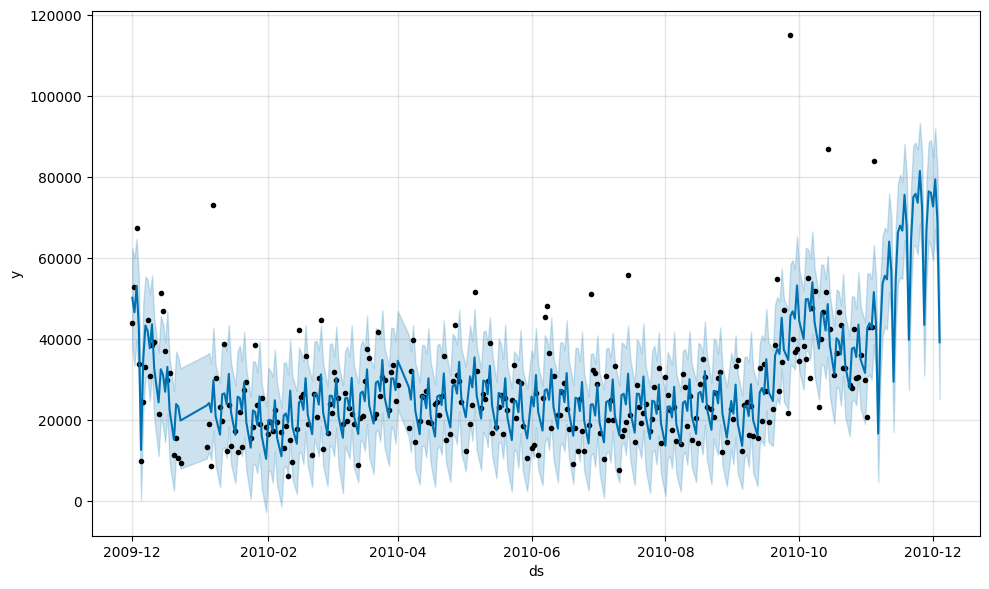

In [27]:
fig = model.plot(forecast)

In [35]:
evaluation = test.merge(
    predictions,
    on="ds"
)

print(evaluation.shape)

(25, 3)


| ds   | y            | yhat            |
| ---- | ------------ | --------------- |
| date | actual sales | predicted sales |


In [ ]:
evaluation.head()

,ds,y,yhat
0,2010-11-05,40907.930,43844.670254
1,2010-11-07,31345.790,42132.692038
2,2010-11-08,32303.991,53668.951611
3,2010-11-09,53013.210,55614.608427
4,2010-11-10,73575.930,54725.764658


In [ ]:
print(evaluation.shape)

(25, 3)


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    evaluation["y"],
    evaluation["yhat"]
)

rmse = np.sqrt(
    mean_squared_error(
        evaluation["y"],
        evaluation["yhat"]
    )
)

mape = (
    np.abs(
        (evaluation["y"] - evaluation["yhat"])
        / evaluation["y"]
    )
).mean() * 100

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("MAPE:", round(mape, 2), "%")

MAE : 23907.4
RMSE: 27086.51
MAPE: 66.16 %


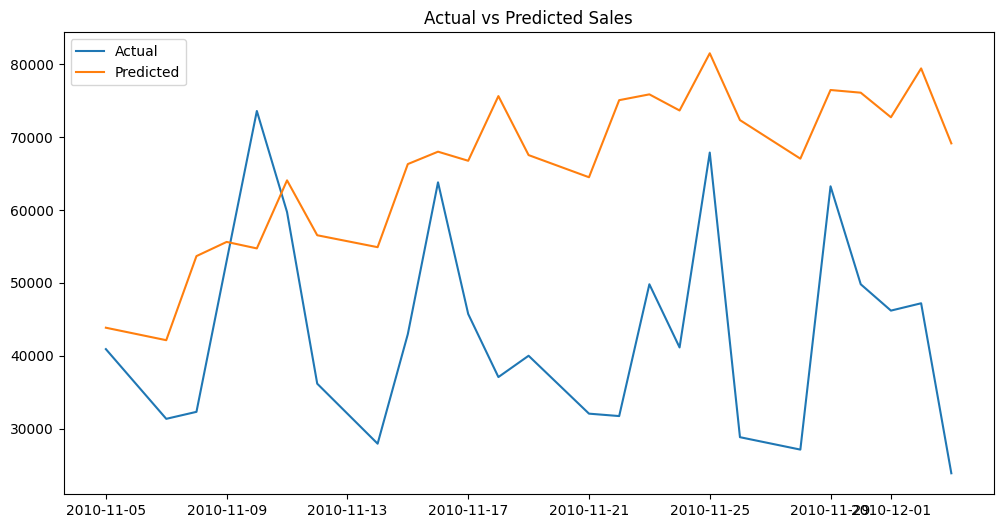

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    evaluation["ds"],
    evaluation["y"],
    label="Actual"
)

plt.plot(
    evaluation["ds"],
    evaluation["yhat"],
    label="Predicted"
)

plt.title("Actual vs Predicted Sales")
plt.legend()

plt.show()

In [40]:
daily_sales.shape

(307, 2)

In [41]:
print(daily_sales["ds"].min())
print(daily_sales["ds"].max())

2009-12-01 00:00:00
2010-12-09 00:00:00


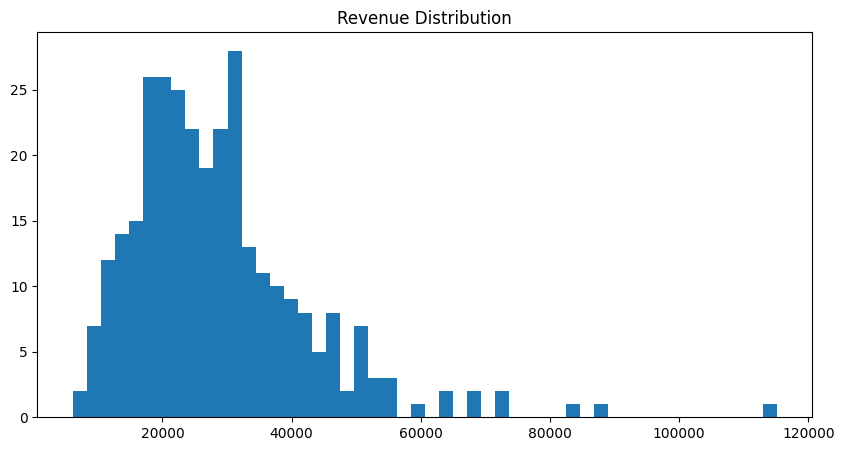

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(daily_sales["y"], bins=50)
plt.title("Revenue Distribution")
plt.show()

In [45]:
forecast.to_csv(
    "../reports/forecasting/forecast_results.csv",
    index=False
)

In [46]:
import pandas as pd

pd.DataFrame([{
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape
}]).to_csv(
    "../reports/forecasting/forecast_metrics.csv",
    index=False
)

In [47]:
from prophet.serialize import model_to_json

with open(
    "../models/forecasting/prophet_model.json",
    "w"
) as fout:
    fout.write(model_to_json(model))

In [48]:
import os

print(os.listdir("../models/forecasting"))
print(os.listdir("../reports/forecasting"))

['prophet_model.json']
['forecast_metrics.csv', 'forecast_results.csv']


In [50]:
import joblib

joblib.dump(
    model,
    "../models/forecasting/prophet_model.pkl"
)

['../models/forecasting/prophet_model.pkl']

In [51]:
import joblib

model = joblib.load(
    "../models/forecasting/prophet_model.pkl"
)